<a href="https://colab.research.google.com/github/Yahir-7/Data_Center_GeoPandas/blob/main/United_States_Population_Density_County_2020.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

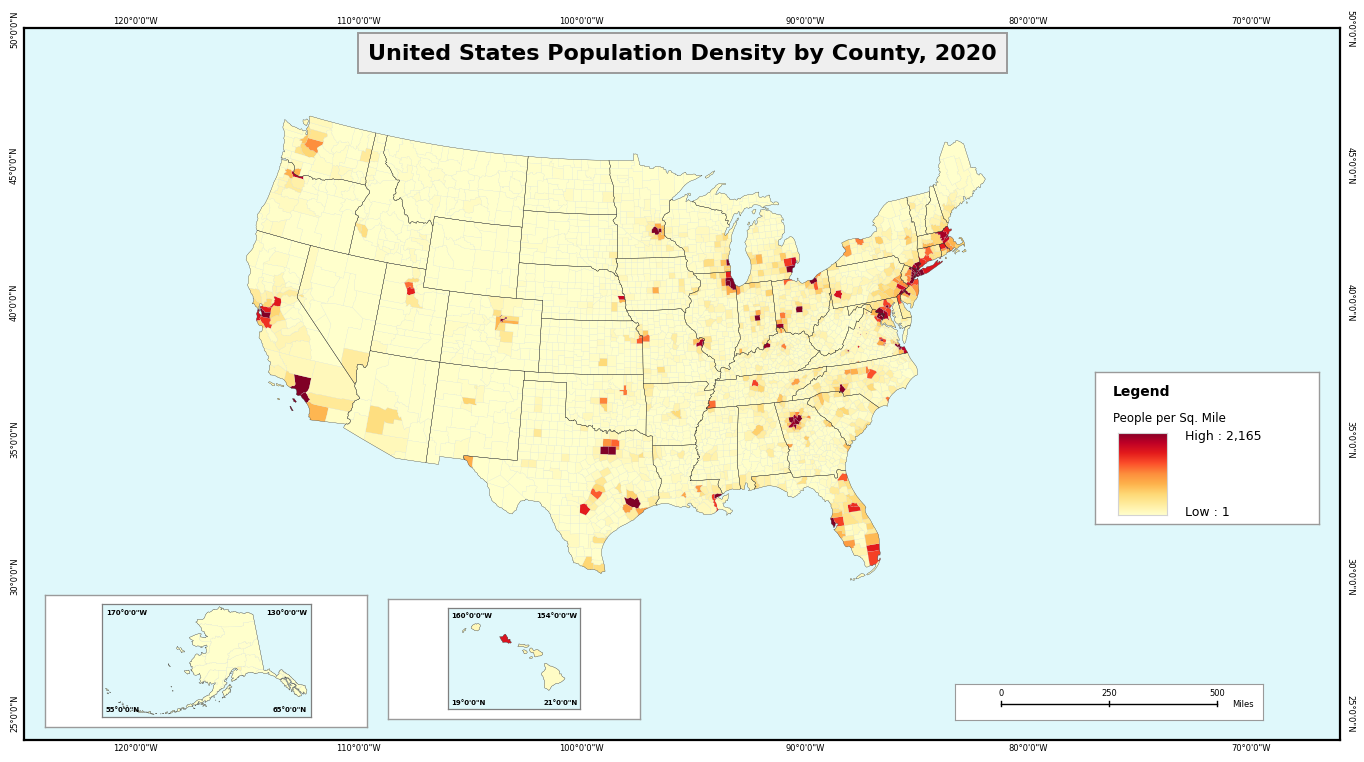

In [16]:
# Run once
# !pip install geopandas pandas numpy matplotlib

# Link to download page: https://data.census.gov/table/DECENNIALPL2020.P1?q=P1+total+population+2020+county
# Use this csv file: DECENNIALPL2020.P1-Column-Metadata.csv

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Read Census population CSV
file = "/content/DECENNIALPL2020.P1-Data.csv"

pop_data = pd.read_csv(file)

# Remove first row if it is a label/description row
pop_data = pop_data[pop_data["GEO_ID"] != "Geography"].copy()

# Keep important columns
population_df = pop_data[[
    "GEO_ID",
    "NAME",
    "P1_001N"
]].copy()

# Rename population column
population_df = population_df.rename(columns={
    "P1_001N": "population"
})

# Make population numeric
population_df["population"] = pd.to_numeric(
    population_df["population"],
    errors="coerce"
)

# Get county FIPS from GEO_ID
# Example: 0500000US01001 -> 01001
population_df["GEOID"] = population_df["GEO_ID"].str[-5:]

# Read county shapefile
county_url = "https://www2.census.gov/geo/tiger/GENZ2020/shp/cb_2020_us_county_20m.zip"

counties = gpd.read_file(county_url)

# Make sure coordinates are latitude/longitude
counties = counties.to_crs(epsg=4326)

# Merge county boundaries with population data
merged = counties.merge(
    population_df,
    on="GEOID",
    how="left"
)

# Remove Puerto Rico and other U.S. territories only
merged = merged[
    ~merged["STUSPS"].isin(["PR", "GU", "VI", "MP", "AS"])
].copy()

# Calculate county land area in square miles
# ALAND is land area in square meters
merged["land_area_sq_miles"] = merged["ALAND"] / 2_589_988.11

# Calculate population density
merged["population_density"] = (
    merged["population"] / merged["land_area_sq_miles"]
)

# Remove missing or infinite values
merged = merged[
    merged["population_density"].notna() &
    np.isfinite(merged["population_density"])
].copy()

# Make colors look better by ignoring extreme outliers
vmin = merged["population_density"].quantile(0.02)
vmax = merged["population_density"].quantile(0.98)

# Split into maps
lower48 = merged[~merged["STUSPS"].isin(["AK", "HI"])].copy()
alaska = merged[merged["STUSPS"] == "AK"].copy()
hawaii = merged[merged["STUSPS"] == "HI"].copy()

# Projections
lower48_proj = lower48.to_crs(epsg=5070)
alaska_proj = alaska.to_crs(epsg=3338)
hawaii_proj = hawaii.to_crs(epsg=4326)

# Create state boundary layers
lower48_states = lower48_proj.dissolve(by="STUSPS")
alaska_states = alaska_proj.dissolve(by="STUSPS") if not alaska_proj.empty else alaska_proj
hawaii_states = hawaii_proj.dissolve(by="STUSPS") if not hawaii_proj.empty else hawaii_proj

# Plot the population density choropleth
def plot_density_map(ax, gdf, linewidth):
    gdf.plot(
        column="population_density",
        cmap="YlOrRd",
        legend=False,
        edgecolor="lightgray",
        linewidth=linewidth,
        vmin=vmin,
        vmax=vmax,
        ax=ax,
        missing_kwds={
            "color": "#eeeeee",
            "edgecolor": "lightgray",
            "linewidth": linewidth
        }
    )

# Convert decimal degrees to degree-minute-second format
def decimal_to_dms(value, is_lon=True):
    if is_lon:
        direction = "W" if value < 0 else "E"
    else:
        direction = "S" if value < 0 else "N"

    value = abs(value)
    degrees = int(value)
    minutes_float = (value - degrees) * 60
    minutes = int(minutes_float)
    seconds = int(round((minutes_float - minutes) * 60))

    if seconds == 60:
        seconds = 0
        minutes += 1

    if minutes == 60:
        minutes = 0
        degrees += 1

    return f"{degrees}°{minutes}'{seconds}\"{direction}"

# Add DMS labels only, without grid lines
def add_dms_frame_labels(
    ax,
    lon_values,
    lat_values,
    lon_min,
    lon_max,
    lat_min,
    lat_max,
    lon_fontsize=6,
    lat_fontsize=6
):
    for lon in lon_values:
        x_frac = (lon - lon_min) / (lon_max - lon_min)
        label = decimal_to_dms(lon, is_lon=True)

        ax.text(
            x_frac,
            1.004,
            label,
            transform=ax.transAxes,
            ha="center",
            va="bottom",
            fontsize=lon_fontsize,
            color="black",
            clip_on=False
        )

        ax.text(
            x_frac,
            -0.004,
            label,
            transform=ax.transAxes,
            ha="center",
            va="top",
            fontsize=lon_fontsize,
            color="black",
            clip_on=False
        )

    for lat in lat_values:
        y_frac = (lat - lat_min) / (lat_max - lat_min)
        label = decimal_to_dms(lat, is_lon=False)

        ax.text(
            -0.004,
            y_frac,
            label,
            transform=ax.transAxes,
            ha="right",
            va="center",
            rotation=90,
            fontsize=lat_fontsize,
            color="black",
            clip_on=False
        )

        ax.text(
            1.004,
            y_frac,
            label,
            transform=ax.transAxes,
            ha="left",
            va="center",
            rotation=270,
            fontsize=lat_fontsize,
            color="black",
            clip_on=False
        )

# Add coordinate labels directly on top of or below an inset map (inside the box)
def add_inset_edge_labels(ax, values, value_min, value_max, is_lon=True, fontsize=4.5, color="black", position="top"):
    n = len(values)
    y_pos = 0.96 if position == "top" else 0.04
    va = "top" if position == "top" else "bottom"

    for i, value in enumerate(values):
        x_frac = (value - value_min) / (value_max - value_min)
        label = decimal_to_dms(value, is_lon=is_lon)

        if i == 0:
            ha = "left"
            x_pos = 0.02
        elif i == n - 1:
            ha = "right"
            x_pos = 0.98
        else:
            ha = "center"
            x_pos = x_frac

        ax.text(
            x_pos,
            y_pos,
            label,
            transform=ax.transAxes,
            ha=ha,
            va=va,
            fontsize=fontsize,
            fontweight="bold",
            color=color,
            zorder=25
        )

# Draw a simple visual scale bar in its own small box
def draw_scale_box(ax, labels=("0", "250", "500"), unit="Miles"):
    ax.set_facecolor("white")

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.8)
        spine.set_edgecolor("#9a9a9a")

    ax.set_xticks([])
    ax.set_yticks([])

    # Main scale line
    ax.plot([0.15, 0.85], [0.45, 0.45], color="black", linewidth=1.0)

    # Tick marks
    ax.plot([0.15, 0.15], [0.38, 0.52], color="black", linewidth=1.0)
    ax.plot([0.50, 0.50], [0.38, 0.52], color="black", linewidth=1.0)
    ax.plot([0.85, 0.85], [0.38, 0.52], color="black", linewidth=1.0)

    # Labels
    ax.text(0.15, 0.62, labels[0], ha="center", va="bottom", fontsize=6)
    ax.text(0.50, 0.62, labels[1], ha="center", va="bottom", fontsize=6)
    ax.text(0.85, 0.62, labels[2], ha="center", va="bottom", fontsize=6)
    ax.text(0.90, 0.45, unit, ha="left", va="center", fontsize=6)

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

# Draw a tiny visual scale bar inside an inset map
def draw_small_inset_scale(ax, labels=("0", "100", "200")):
    ax.plot(
        [0.55, 0.88],
        [0.10, 0.10],
        transform=ax.transAxes,
        color="black",
        linewidth=0.8,
        zorder=20
    )

    ax.plot(
        [0.55, 0.55],
        [0.075, 0.125],
        transform=ax.transAxes,
        color="black",
        linewidth=0.8,
        zorder=20
    )

    ax.plot(
        [0.715, 0.715],
        [0.075, 0.125],
        transform=ax.transAxes,
        color="black",
        linewidth=0.8,
        zorder=20
    )

    ax.plot(
        [0.88, 0.88],
        [0.075, 0.125],
        transform=ax.transAxes,
        color="black",
        linewidth=0.8,
        zorder=20
    )

    ax.text(
        0.55,
        0.145,
        labels[0],
        transform=ax.transAxes,
        ha="center",
        va="bottom",
        fontsize=4.5,
        zorder=21
    )

    ax.text(
        0.715,
        0.145,
        labels[1],
        transform=ax.transAxes,
        ha="center",
        va="bottom",
        fontsize=4.5,
        zorder=21
    )

    ax.text(
        0.88,
        0.145,
        labels[2],
        transform=ax.transAxes,
        ha="center",
        va="bottom",
        fontsize=4.5,
        zorder=21
    )

    ax.text(
        0.895,
        0.10,
        "Miles",
        transform=ax.transAxes,
        ha="left",
        va="center",
        fontsize=4.5,
        zorder=21
    )

# Figure layout
fig = plt.figure(figsize=(14, 8), facecolor="white")

# Background frame that fills the whole map layout
ax_frame_bg = fig.add_axes([0.025, 0.045, 0.94, 0.89], zorder=0)
ax_frame_bg.set_facecolor("#dff8fb")

for spine in ax_frame_bg.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.2)
    spine.set_edgecolor("#7f7f7f")

ax_frame_bg.set_xticks([])
ax_frame_bg.set_yticks([])

# Main lower 48 map
ax_main = fig.add_axes([0.045, 0.210, 0.805, 0.650], zorder=2)
ax_main.set_facecolor("#dff8fb")

# Plot population density map
plot_density_map(ax_main, lower48_proj, 0.08)

# Thin black state borders
lower48_states.boundary.plot(
    ax=ax_main,
    color="black",
    linewidth=0.18,
    zorder=4
)

# Keep main map centered and fitted
minx, miny, maxx, maxy = lower48_proj.total_bounds
x_buffer = (maxx - minx) * 0.030
y_buffer = (maxy - miny) * 0.060

ax_main.set_xlim(minx - x_buffer, maxx + x_buffer)
ax_main.set_ylim(miny - y_buffer, maxy + y_buffer)

# Remove the inner main-map border so only the big outer border shows
for spine in ax_main.spines.values():
    spine.set_visible(False)

ax_main.set_xticks([])
ax_main.set_yticks([])

# Alaska outer white box
ak_outer = fig.add_axes([0.040, 0.062, 0.230, 0.165], zorder=4)
ak_outer.set_facecolor("white")

for spine in ak_outer.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.0)
    spine.set_edgecolor("#9a9a9a")

ak_outer.set_xticks([])
ak_outer.set_yticks([])

# Alaska inner map box
ak_inner_left = 0.020
ak_inner_bottom = 0.075
ak_inner_width = 0.960
ak_inner_height = 0.850

ax_ak = ak_outer.inset_axes([
    ak_inner_left,
    ak_inner_bottom,
    ak_inner_width,
    ak_inner_height
])

ax_ak.set_facecolor("#dff8fb")

if not alaska_proj.empty:
    plot_density_map(ax_ak, alaska_proj, 0.10)
    alaska_states.boundary.plot(
        ax=ax_ak,
        color="black",
        linewidth=0.20,
        zorder=4
    )

    minx, miny, maxx, maxy = alaska_proj.total_bounds
    x_buffer = (maxx - minx) * 0.02
    y_buffer = (maxy - miny) * 0.02
    ax_ak.set_xlim(minx - x_buffer, maxx + x_buffer)
    ax_ak.set_ylim(miny - y_buffer, maxy + y_buffer)

for spine in ax_ak.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.9)
    spine.set_edgecolor("#7f7f7f")

ax_ak.set_xticks([])
ax_ak.set_yticks([])

# Alaska longitude labels, overlaid on top of the map
add_inset_edge_labels(
    ax=ax_ak,
    values=[-170, -130],
    value_min=-180,
    value_max=-130,
    is_lon=True,
    fontsize=5,
    position="top"
)

# Alaska latitude labels, overlaid on the bottom of the map
add_inset_edge_labels(
    ax=ax_ak,
    values=[55, 65],
    value_min=50,
    value_max=72,
    is_lon=False,
    fontsize=5,
    position="bottom"
)

# Hawaii outer white box
hi_outer = fig.add_axes([0.285, 0.072, 0.180, 0.150], zorder=4)
hi_outer.set_facecolor("white")

for spine in hi_outer.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.0)
    spine.set_edgecolor("#9a9a9a")

hi_outer.set_xticks([])
hi_outer.set_yticks([])

# Hawaii inner map box
hi_inner_left = 0.025
hi_inner_bottom = 0.080
hi_inner_width = 0.950
hi_inner_height = 0.840

ax_hi = hi_outer.inset_axes([
    hi_inner_left,
    hi_inner_bottom,
    hi_inner_width,
    hi_inner_height
])

ax_hi.set_facecolor("#dff8fb")

if not hawaii_proj.empty:
    plot_density_map(ax_hi, hawaii_proj, 0.10)
    hawaii_states.boundary.plot(
        ax=ax_hi,
        color="black",
        linewidth=0.20,
        zorder=4
    )

ax_hi.set_xlim(-161, -154)
ax_hi.set_ylim(18, 23)

for spine in ax_hi.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.9)
    spine.set_edgecolor("#7f7f7f")

ax_hi.set_xticks([])
ax_hi.set_yticks([])

# Hawaii longitude labels, overlaid on top of the map
add_inset_edge_labels(
    ax=ax_hi,
    values=[-160, -154],
    value_min=-161,
    value_max=-154,
    is_lon=True,
    fontsize=5,
    position="top"
)

# Hawaii latitude labels, overlaid on the bottom of the map
add_inset_edge_labels(
    ax=ax_hi,
    values=[19, 21],
    value_min=18,
    value_max=23,
    is_lon=False,
    fontsize=5,
    position="bottom"
)

# Main scale bar in bottom-right corner
ax_scale = fig.add_axes([0.690, 0.070, 0.220, 0.045], zorder=4)
draw_scale_box(ax_scale, labels=("0", "250", "500"), unit="Miles")

# Legend box
ax_leg = fig.add_axes([0.790, 0.315, 0.160, 0.190], zorder=4)
ax_leg.set_facecolor("white")

for spine in ax_leg.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.0)
    spine.set_edgecolor("#9a9a9a")

ax_leg.set_xticks([])
ax_leg.set_yticks([])

# Legend title
ax_leg.text(
    0.08,
    0.92,
    "Legend",
    fontsize=10,
    fontweight="bold",
    ha="left",
    va="top"
)

ax_leg.text(
    0.08,
    0.74,
    "People per Sq. Mile",
    fontsize=8.5,
    ha="left",
    va="top"
)

# Gradient color scale inside legend
scale_ax = ax_leg.inset_axes([0.10, 0.06, 0.22, 0.54])

gradient = np.linspace(vmax, vmin, 256).reshape(256, 1)

scale_ax.imshow(
    gradient,
    aspect="auto",
    cmap="YlOrRd"
)

scale_ax.set_xticks([])
scale_ax.set_yticks([])

for spine in scale_ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.8)
    spine.set_edgecolor("lightgray")

# High / Low labels, aligned with the top and bottom of the gradient bar
ax_leg.text(
    0.40,
    0.58,
    f"High : {vmax:,.0f}",
    fontsize=9,
    ha="left",
    va="center"
)

ax_leg.text(
    0.40,
    0.08,
    f"Low : {vmin:,.0f}",
    fontsize=9,
    ha="left",
    va="center"
)

# Transparent top frame for border, coordinate labels, and title
ax_frame = fig.add_axes([0.025, 0.045, 0.94, 0.89], zorder=10)
ax_frame.patch.set_alpha(0)

for spine in ax_frame.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.6)
    spine.set_edgecolor("black")

ax_frame.set_xticks([])
ax_frame.set_yticks([])

# DMS coordinate labels around the whole map layout
add_dms_frame_labels(
    ax=ax_frame,
    lon_values=[-120, -110, -100, -90, -80, -70],
    lat_values=[25, 30, 35, 40, 45, 50],
    lon_min=-125,
    lon_max=-66,
    lat_min=24,
    lat_max=50,
    lon_fontsize=6,
    lat_fontsize=6
)

# Title inside the big frame
ax_frame.text(
    0.5,
    0.965,
    "United States Population Density by County, 2020",
    transform=ax_frame.transAxes,
    ha="center",
    va="center",
    fontsize=16,
    fontweight="bold",
    bbox=dict(
        facecolor="#efefef",
        edgecolor="#9a9a9a",
        boxstyle="square,pad=0.45",
        linewidth=1.4
    ),
    zorder=20
)

plt.show()